# 네이버 영화리뷰 감성 분석

### 01. 데이터 로드

**✅ 실습 과제**
- [네이버 영화 리뷰 데이터셋](https://raw.githubusercontent.com/e9t/nsmc/master/ratings.txt)을 불러온다.
- 데이터의 컬럼 구성과 샘플을 확인한다.

In [1]:
# 데이터 다운로드
from tensorflow.keras.utils import get_file

ratings_train_path = get_file("ratings_train.txt", "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt")
ratings_test_path = get_file("ratings_test.txt", "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt")

ratings_train_path, ratings_test_path

('C:\\Users\\yunu2\\.keras\\datasets\\ratings_train.txt',
 'C:\\Users\\yunu2\\.keras\\datasets\\ratings_test.txt')

In [ ]:
# 데이터프레임 생성
import pandas as pd

# 탭(\t)을 구분자로 사용하여 각각의 데이터프레임으로 불러오기
train_df = pd.read_csv(ratings_train_path, sep='\t')
test_df = pd.read_csv(ratings_test_path, sep='\t')

In [3]:
display(train_df.head())

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [5]:
display(test_df.head())

,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0


In [ ]:
# train 데이터셋 각각 컬럼 개수 -> 결측값 처리에 참고
train_df.count()

id          150000
document    149995
label       150000
dtype: int64

In [ ]:
# test 데이터셋 각각 컬럼 개수 -> 결측값 처리에 참고
test_df.count()

id          50000
document    49997
label       50000
dtype: int64

**🔍 확인 질문**

**1. 리뷰 텍스트와 정답 라벨은 각각 어떤 컬럼에 저장되어 있는가?**
- 리뷰 텍스트는 'document' 컬럼에, 정답 라벨은 'label' 컬럼에 저장되어있다.

**2. 긍정 / 부정 라벨은 어떤 값으로 표현되어 있는가?**
- 긍정은 1로, 부정은 0으로 표현되어있다.

In [7]:
# 데이터 샘플링: train은 10000개만, test는 3000개만

train_df = train_df.sample(n=10000, random_state=42).reset_index(drop=True)
test_df = test_df.sample(n=3000, random_state=42).reset_index(drop=True)

print(train_df.shape, test_df.shape)
display(train_df.head())

(10000, 3) (3000, 3)


,id,document,label
0,8932939,수OO만에 다시보네여,1
1,3681731,일방적인 영화다. 관객 좀 고려해주시길,0
2,9847174,세상을 초월하는 한 사람의 선한 마음,1
3,8506899,멍하다.. 여러생각이 겹치는데 오랜만에 영화 보고 이런 느낌 느껴본다,1
4,9991656,"우와 별 반개도 아까운판에 밑에 CJ 알바생들 쩐다.. 전부 만점이야 ㅎㅎㅎ..,....",0


### 02. 데이터 전처리

##### 02-01. 한글 전처리

**✅ 실습 과제**
- 특수문자, 숫자, 불필요한 기호를 제거한다.
- 정규표현식을 사용하여 한글만 남긴다.


In [8]:
# 결측치 제거 - train
train_df = train_df.dropna()
print(train_df.count())

# 결측치 제거 - test
test_df = test_df.dropna()
print(test_df.count())

id          9999
document    9999
label       9999
dtype: int64
id          2999
document    2999
label       2999
dtype: int64


In [ ]:
# 1. 한글만 남기기
import re

def clean_korean_text(text):
    text = str(text)

    # 한글, 공백만 남기기
    text = re.sub(r'[^가-힣\s]', ' ', text)

    # 공백 정리
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
# 2. 형태소 분석 - Okt 활용

from konlpy.tag import Okt

okt = Okt()

stop_words = {
    '의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다'
}

def tokenize_korean_okt(text):
    text = clean_korean_text(text)

    tokens = []

    # stem=True: 동사/형용사 원형 복원
    for word, tag in okt.pos(text, stem=True):
        # 조사, 어미, 구두점 제거
        if tag in ['Josa', 'Eomi', 'Punctuation']:
            continue

        # 불용어 제거
        if word in stop_words:
            continue

        # 자모만 있는 토큰 제거
        if re.fullmatch(r'[ㄱ-ㅎㅏ-ㅣ]+', word):
            continue

        # 공백/빈 문자열 제거
        if not word.strip():
            continue

        tokens.append(word)

    return tokens

In [11]:
# 3. 데이터프레임 적용을 위한 함수
def preprocess_dataframe_okt(df, text_col='document'):
    df = df.copy()

    # 문자열 정제
    df['clean_text'] = df[text_col].apply(clean_korean_text)

    # 빈 문자열 제거
    df = df[df['clean_text'].str.strip() != ''].copy()

    # 토큰화
    df['tokens'] = df['clean_text'].apply(tokenize_korean_okt)

    # 토큰이 없는 행 제거
    df = df[df['tokens'].map(len) > 0].copy()

    return df

In [ ]:
# document에 okt를 활용한 전처리 적용
train_df = preprocess_dataframe_okt(train_df, text_col='document')
test_df = preprocess_dataframe_okt(test_df, text_col='document')

                                            document  \
0                                        수OO만에 다시보네여   
1                              일방적인 영화다. 관객 좀 고려해주시길   
2                               세상을 초월하는 한 사람의 선한 마음   
3             멍하다.. 여러생각이 겹치는데 오랜만에 영화 보고 이런 느낌 느껴본다   
4  우와 별 반개도 아까운판에 밑에 CJ 알바생들 쩐다.. 전부 만점이야 ㅎㅎㅎ..,....   

                                          clean_text  \
0                                         수 만에 다시보네여   
1                               일방적인 영화다 관객 좀 고려해주시길   
2                               세상을 초월하는 한 사람의 선한 마음   
3               멍하다 여러생각이 겹치는데 오랜만에 영화 보고 이런 느낌 느껴본다   
4  우와 별 반개도 아까운판에 밑에 알바생들 쩐다 전부 만점이야 야 그만해라 저영화는 ...   

                                              tokens  
0                                        [수, 다시, 보다]  
1                           [일방, 적, 영화, 관객, 고려, 해주다]  
2                              [세상, 초월, 사람, 선하다, 마음]  
3  [멍하다, 여러, 생각, 겹, 치다, 오랜, 만, 영화, 보고, 이렇다, 느낌, 느...  
4  [우와, 별, 반개, 아깝다, 판, 밑, 알바생, 쩐다, 전부, 만점, 야, 그만하..

**🔍 확인 질문**
1. 한국어 전처리를 하지 않으면 어떤 문제가 발생할 수 있는가?
- 한국어의 경우 교착어이기 때문에 각종 조사들이 많고, 용언(동사, 형용사)의 활용형이 많다는 특징을 지닌다. 전처리를 하지 않는다면 모델을 학습하는 데에 성능과 효율이 떨어진다.

2. 감성 분석에서 이모지나 느낌표는 제거하는 것이 항상 옳은가?
- 이모지 혹은 느낌표가 감성을 나타내는 경우도 있기 때문에 무조건 제거해야하는 것이 옳은 것은 아니다. 이모지 혹은 느낌표의 개수가 감정의 심화된 정도를 나타내기도 한다.

##### 02-02. Tokenizing & Sequencing

**✅ 실습 과제**
- Tokenizer를 사용해 단어 사전을 생성한다.
- 문장을 정수 시퀀스로 변환한다.
- padding을 적용하여 시퀀스 길이를 맞춘다.

In [13]:
# torchtext에서 버전 충돌 이슈로 오류가 발생하여 새로운 함수를 만들어줌
from collections import Counter

# train_df['tokens'] 기준으로 단어 빈도 세기
counter = Counter()

for tokens in train_df['tokens']:
    counter.update(tokens)

# 특수 토큰
vocab = {
    '<pad>': 0,
    '<unk>': 1
}

# min_freq=2와 같은 효과
for word, freq in counter.items():
    if freq >= 2:
        vocab[word] = len(vocab)

print("vocab 크기:", len(vocab))
print("pad index:", vocab['<pad>'])
print("unk index:", vocab['<unk>'])

vocab 크기: 5746
pad index: 0
unk index: 1


In [14]:
# 토큰 리스트를 정수로 변환
def tokens_to_sequence(tokens, vocab):
    return [vocab.get(token, vocab['<unk>']) for token in tokens]

train_df['seq'] = train_df['tokens'].apply(lambda x: tokens_to_sequence(x, vocab))
test_df['seq'] = test_df['tokens'].apply(lambda x: tokens_to_sequence(x, vocab))

train_df[['tokens', 'seq']]
test_df[['tokens', 'seq']]

,tokens,seq
0,"[모든, 편견, 날다, 버리다, 가슴, 따뜻하다, 영화, 로버트, 드, 니, 필립,...","[485, 1530, 2164, 147, 261, 1388, 7, 420, 977,..."
1,"[무한, 리메이크, 소재, 감독, 역량, 항상, 그, 자리]","[4423, 1559, 509, 100, 5343, 2331, 312, 2307]"
2,"[신나다, 것, 없다, 애니]","[1108, 229, 68, 619]"
3,"[잔잔, 격동]","[1, 1]"
4,"[오랜, 만, 찾다, 주말, 명화, 보석]","[19, 20, 230, 4211, 2792, 4055]"
...,...,...
2995,"[년, 중국, 유학, 시, 남자, 의리, 정의, 대해, 눈물, 흘리다]","[319, 2787, 5534, 1201, 285, 816, 98, 169, 605..."
2996,"[일단, 재미, 없다, 모든, 배우, 연기, 불편하다, 다가오다]","[2841, 214, 68, 485, 200, 210, 1579, 2530]"
2997,"[액션, 시작, 멜로, 끝나다]","[180, 128, 209, 1115]"
2998,"[개, 재미없다, 유치하다, 억, 지, 감동, 핵, 노잼, 이영화, 가왜, 떳, 늘...","[190, 97, 790, 1865, 1051, 547, 1769, 983, 96,..."


In [15]:
from collections import Counter

class TokenizerForPadding:
    def __init__(self, num_words=None, oov_token='<OOV>', pad_token='<PAD>'):
        self.num_words = num_words
        self.oov_token = oov_token      # oov 부여
        self.pad_token = pad_token      # pad 부여
        self.word_index = {}
        self.index_word = {}
        self.word_counts = Counter()

    def fit_on_texts(self, texts):
        # texts: 토큰 리스트들의 리스트
        for sentence in texts:
            self.word_counts.update(word for word in sentence if word)

        # 실제 단어 개수 제한
        if self.num_words:
            most_common_words = [
                word for word, _ in self.word_counts.most_common(self.num_words - 2)
            ]
        else:
            most_common_words = list(self.word_counts.keys())

        # 0:<PAD>, 1:<OOV>, 2부터 실제 단어
        vocab = [self.pad_token, self.oov_token] + most_common_words

        self.word_index = {word: i for i, word in enumerate(vocab)}
        self.index_word = {i: word for word, i in self.word_index.items()}

    def texts_to_sequences(self, texts):
        return [
            [self.word_index.get(word, self.word_index[self.oov_token]) for word in sentence]
            for sentence in texts
        ]

In [16]:
# 패딩 처리
def pad_sequences_custom(sequences, maxlen, padding='post', truncating='post', value=0):
    padded_sequences = []

    for seq in sequences:
        seq = list(seq)

        # truncating
        if len(seq) > maxlen:
            if truncating == 'post':
                seq = seq[:maxlen]
            elif truncating == 'pre':
                seq = seq[-maxlen:]

        # padding
        if len(seq) < maxlen:
            pad_length = maxlen - len(seq)
            if padding == 'post':
                seq = seq + [value] * pad_length
            elif padding == 'pre':
                seq = [value] * pad_length + seq

        padded_sequences.append(seq)

    return padded_sequences

In [17]:
# 토큰 리스트 준비
train_tokens = train_df['tokens'].tolist()
test_tokens = test_df['tokens'].tolist()

# tokenizer 생성 및 학습
tokenizer = TokenizerForPadding(num_words=10000)
tokenizer.fit_on_texts(train_tokens)

In [18]:
train_sequences = tokenizer.texts_to_sequences(train_tokens)
test_sequences = tokenizer.texts_to_sequences(test_tokens)

In [19]:
max_len = 30

X_train = pad_sequences_custom(
    train_sequences,
    maxlen=max_len,
    padding='post',
    truncating='post',
    value=tokenizer.word_index['<PAD>']
)

X_test = pad_sequences_custom(
    test_sequences,
    maxlen=max_len,
    padding='post',
    truncating='post',
    value=tokenizer.word_index['<PAD>']
)

y_train = train_df['label'].tolist()
y_test = test_df['label'].tolist()

In [20]:
import torch

X_train = torch.tensor(X_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

torch.Size([9883, 30]) torch.Size([2961, 30])
torch.Size([9883]) torch.Size([2961])


In [21]:
sequences = train_sequences[:5]

padded = pad_sequences_custom(
    sequences,
    maxlen=10,
    padding='post',
    truncating='post',
    value=tokenizer.word_index['<PAD>']
)

print("원래 시퀀스:")
for seq in sequences:
    print(seq)

print("\n패딩 후 시퀀스:")
for seq in padded:
    print(seq)

원래 시퀀스:
[53, 64, 3]
[3966, 11, 2, 295, 5746, 115]
[281, 2485, 31, 3065, 149]
[5747, 687, 28, 2118, 233, 282, 95, 2, 42, 36, 123, 106, 3]
[1503, 112, 811, 40, 413, 469, 2119, 1174, 688, 392, 1095, 1504, 78, 2, 8, 55, 150, 1376, 5748, 81, 939, 5749, 322, 5750, 2, 3967, 3, 2486, 3, 88, 40, 44, 40]

패딩 후 시퀀스:
[53, 64, 3, 0, 0, 0, 0, 0, 0, 0]
[3966, 11, 2, 295, 5746, 115, 0, 0, 0, 0]
[281, 2485, 31, 3065, 149, 0, 0, 0, 0, 0]
[5747, 687, 28, 2118, 233, 282, 95, 2, 42, 36]
[1503, 112, 811, 40, 413, 469, 2119, 1174, 688, 392]


**🔍 확인 질문**
1. `num_words` 파라미터는 어떤 역할을 하는가?
- 단어사전에 넣을 단어 개수를 얼마나 제한할지를 정하는 역할. 

ex) num_words=10000이면 상위 빈도 10000개 정도만 사용

2. padding을 하지 않으면 배치 학습에서 어떤 문제가 발생하는가?
- padding은 문장의 토큰 개수를 맞춰주는 것인데 padding을 해주지 않으면 데이터를 효율적으로 처리하기 어렵다는 문제가 발생.


ex) 한 문장은 토큰의 개수가 20개이고, 또 다른 문장은 토큰이 3개라면?

##### 02-03. Sequence Decoding

**✅ 실습 과제**
- 정수 시퀀스를 다시 텍스트로 복원해본다.
- 토큰 인덱스와 단어의 매핑 관계를 확인한다.

In [22]:
print(tokenizer.word_index)
print(tokenizer.index_word)

{'<PAD>': 0, '<OOV>': 1, '영화': 2, '보다': 3, '없다': 4, '있다': 5, '좋다': 6, '너무': 7, '정말': 8, '재밌다': 9, '되다': 10, '적': 11, '이다': 12, '진짜': 13, '점': 14, '같다': 15, '아니다': 16, '않다': 17, '연기': 18, '나오다': 19, '만들다': 20, '것': 21, '안': 22, '평점': 23, '내': 24, '못': 25, '최고': 26, '다': 27, '생각': 28, '그': 29, '스토리': 30, '사람': 31, '드라마': 32, '왜': 33, '감동': 34, '말': 35, '이렇다': 36, '배우': 37, '감독': 38, '때': 39, '아깝다': 40, '그냥': 41, '보고': 42, '거': 43, '시간': 44, '재미있다': 45, '더': 46, '내용': 47, '재미': 48, '재미없다': 49, '중': 50, '뭐': 51, '자다': 52, '수': 53, '지루하다': 54, '쓰레기': 55, '가다': 56, '주다': 57, '나': 58, '하나': 59, '그렇다': 60, '아': 61, '볼': 62, '알다': 63, '다시': 64, '들다': 65, '사랑': 66, '작품': 67, '모르다': 68, '액션': 69, '싶다': 70, '완전': 71, '마지막': 72, '많다': 73, '처음': 74, '장면': 75, '이렇게': 76, '이건': 77, '저': 78, '정도': 79, '주인공': 80, '나다': 81, '명작': 82, '연출': 83, '최악': 84, '기': 85, '안되다': 86, '오다': 87, '돈': 88, '하': 89, '분': 90, '년': 91, '지금': 92, '역시': 93, '걸': 94, '만': 95, '차다': 96, '끝': 97, '네': 98, '개': 99, '좋아하다': 100,

In [23]:
# 정수 시퀀스를 텍스트로 복원해주는 함수
def decode_sequence(sequence, index_word, pad_index=0):
    words = []
    for idx in sequence:
        if idx == pad_index:
            continue
        words.append(index_word.get(idx, '<OOV>'))      # OOV 토큰 
    return words

In [24]:
seq = [2, 12, 5, 0, 0, 0]
decoded = decode_sequence(seq, tokenizer.index_word, pad_index=tokenizer.word_index['<PAD>'])
print(decoded)

['영화', '이다', '있다']


**🔍 확인 질문**
1. `<OOV>` 토큰은 언제 사용되는가?
- 단어사전에 정의되지 않은 단어들을 처리해줄 때 사용한다.

2. 디코딩 결과가 원문과 완전히 동일하지 않은 이유는 무엇인가?
- 디코딩을 하기 전 여러 전처리(불용어 처리, 용언에 대한 처리, 한국어만 추출...)를 거쳤기 때문에 원문과 다르다.

### 03. 모델 생성 및 학습

**✅ 실습 과제**
- Embedding Layer를 포함한 감성분석 모델을 정의한다.
- 손실 함수와 옵티마이저를 설정한다.
- 학습 과정을 통해 loss 변화를 확인한다.

In [36]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split

# tensor 변환
X_train_padded = torch.tensor(X_train_padded, dtype=torch.long)
X_test_padded = torch.tensor(X_test_padded, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# train / validation 분리
batch_size = 64
train_size = int(len(X_train_padded) * 0.8)
val_size = len(X_train_padded) - train_size

full_train_dataset = TensorDataset(X_train_padded, y_train)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

test_dataset = TensorDataset(X_test_padded, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

C:\Users\yunu2\AppData\Local\Temp\ipykernel_35012\2680936869.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_padded = torch.tensor(X_train_padded, dtype=torch.long)
C:\Users\yunu2\AppData\Local\Temp\ipykernel_35012\2680936869.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_padded = torch.tensor(X_test_padded, dtype=torch.long)
C:\Users\yunu2\AppData\Local\Temp\ipykernel_35012\2680936869.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32)
C:\Users\yunu2\AppData\Loc

### 03-1. 감성분석 모델 정의 (GRU)

In [37]:
# 1. 함수 정의

import torch
import torch.nn as nn

class SentimentGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, X):
        X = self.embedding(X)
        out, h_s = self.gru(X)
        output = self.fc(h_s[-1])
        return output.squeeze(1)

vocab_size = max(tokenizer.word_index.values()) + 1

In [38]:
# 2. 모델 학습
model = SentimentGRU(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_size=64,
    pad_idx=tokenizer.word_index['<PAD>']
)

print(model)

SentimentGRU(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (gru): GRU(128, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


### 03-2. 손실함수, 옵티마이저 설정

In [39]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)

### 03-3. 학습 함수 정의

In [40]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        proba = torch.sigmoid(output)
        pred = (proba >= 0.5).float()
        train_correct += (pred == y_batch).sum().item()
        train_total += y_batch.size(0)

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    return train_loss, train_acc


def val_epoch(model, val_loader, criterion, device):
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val = X_val.to(device)
            y_val = y_val.to(device)

            output = model(X_val)
            loss = criterion(output, y_val)

            val_loss += loss.item()

            proba = torch.sigmoid(output)
            pred = (proba >= 0.5).float()
            val_correct += (pred == y_val).sum().item()
            val_total += y_val.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    return val_loss, val_acc

### 03-4. 모델 학습 함수

In [41]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001, early_stopping_patience=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_val_loss = float('inf')
    best_model_state = None
    early_stopping_counter = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = val_epoch(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2%} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2%}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1
            if early_stopping_counter >= early_stopping_patience:
                print(f"Early Stopped at Epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history

### 04-5. 모델 학습 실행

In [42]:
trained_model, history = train_model(
    model,
    train_loader,
    val_loader,
    epochs=20,
    lr=0.001,
    early_stopping_patience=5
)

Epoch [1/20] | Train Loss: 0.6934, Train Acc: 50.09% | Val Loss: 0.6937, Val Acc: 49.87%
Epoch [2/20] | Train Loss: 0.6876, Train Acc: 50.77% | Val Loss: 0.6942, Val Acc: 50.18%
Epoch [3/20] | Train Loss: 0.6092, Train Acc: 65.03% | Val Loss: 0.5257, Val Acc: 74.15%
Epoch [4/20] | Train Loss: 0.4281, Train Acc: 80.99% | Val Loss: 0.5006, Val Acc: 76.07%
Epoch [5/20] | Train Loss: 0.3261, Train Acc: 87.01% | Val Loss: 0.5050, Val Acc: 76.23%
Epoch [6/20] | Train Loss: 0.2327, Train Acc: 91.66% | Val Loss: 0.5592, Val Acc: 76.88%
Epoch [7/20] | Train Loss: 0.1704, Train Acc: 94.45% | Val Loss: 0.6571, Val Acc: 76.48%
Epoch [8/20] | Train Loss: 0.1193, Train Acc: 96.36% | Val Loss: 0.7968, Val Acc: 76.07%
Epoch [9/20] | Train Loss: 0.0955, Train Acc: 97.26% | Val Loss: 0.8062, Val Acc: 76.07%
Early Stopped at Epoch 9


**🔍 확인 질문**
1. Embedding Layer는 어떤 역할을 하는가?
- 자연어가 가진 시계열적인 특성을 이해하고 그에 따른 결과를 낼 수 있게 한다.

2. One-hot 인코딩 대신 Embedding을 사용하는 이유는 무엇인가?
- 

### 04. 모델 평가

**✅ 실습 과제**
- 검증 데이터로 모델 성능을 평가한다.
- 정확도(acc)와 손실(loss)을 확인한다.

In [34]:
criterion = nn.BCEWithLogitsLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

val_loss, val_acc = val_epoch(trained_model, val_loader, criterion, device)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Validation Loss: 0.7239
Validation Accuracy: 0.7785


In [43]:
def test_epoch(model, test_loader, criterion, device):
    model.eval()
    test_loss, test_correct, test_total = 0, 0, 0

    with torch.no_grad():
        for X_test_batch, y_test_batch in test_loader:
            X_test_batch = X_test_batch.to(device)
            y_test_batch = y_test_batch.to(device)

            output = model(X_test_batch)
            loss = criterion(output, y_test_batch)

            test_loss += loss.item()

            proba = torch.sigmoid(output)
            pred = (proba >= 0.5).float()

            test_correct += (pred == y_test_batch).sum().item()
            test_total += y_test_batch.size(0)

    test_loss /= len(test_loader)
    test_acc = test_correct / test_total
    return test_loss, test_acc

test_loss, test_acc = test_epoch(trained_model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.8161
Test Accuracy: 0.7545


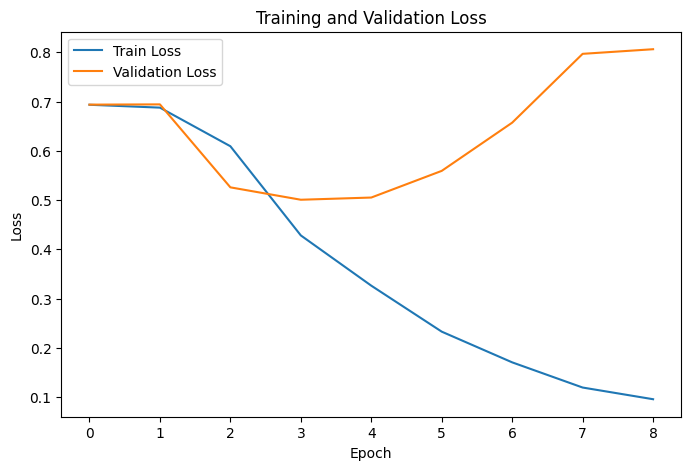

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

**🔍 확인 질문**
1. 학습 데이터 성능과 평가 데이터 성능 차이가 의미하는 것은 무엇인가?
- 학습 데이터 성능보다 평가 데이터 성능이 높다면, 이는 과소 적합을 의미한다. 반대의 경우 과대적합을 의미한다.

2. 과적합 여부는 어떻게 판단할 수 있는가?
- 시각화 그래프에서 epoch이 3이상으로 갈 때 Train Loss는 급격히 떨어지고 Train Loss는 감소하였다가 증가하는 것으로 보아 해당 데이터는 과대적합이 있음을 알 수 있다.

### 05. 모델 추론

**✅ 실습 과제**
- 임의의 문장을 입력하여 감성을 예측한다.
- 출력 확률을 기반으로 긍/부정을 해석한다.

**🔍 확인 질문**
1. 모델 출력값은 확률인가 점수인가?
2. 기준값(threshold)은 왜 필요한가?

In [45]:
def predict_sentiment(text, model, tokenizer, max_len, device):
    model.eval()

    # 1) 전처리 + 토큰화
    tokens = tokenize_korean_okt(text)

    # 2) 정수 시퀀스 변환
    sequence = tokenizer.texts_to_sequences([tokens])

    # 3) padding
    padded = pad_sequences_custom(
        sequence,
        maxlen=max_len,
        padding='post',
        truncating='post',
        value=tokenizer.word_index['<PAD>']
    )

    # 4) tensor 변환
    x = torch.tensor(padded, dtype=torch.long).to(device)

    # 5) 예측
    with torch.no_grad():
        output = model(x)                  # logit
        prob = torch.sigmoid(output).item()  # 확률값

    # 6) 공/부정 해석
    pred = 1 if prob >= 0.5 else 0
    sentiment = "긍정" if pred == 1 else "부정"

    return {
        '입력문장': text,
        '토큰화결과': tokens,
        '예측확률': prob,
        '예측라벨': pred,
        '감성해석': sentiment
    }

In [47]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

result1 = predict_sentiment(
    "이 영화는 정말 재미있고 감동적이었어요",
    trained_model,
    tokenizer,
    max_len=30,
    device=device
)

result2 = predict_sentiment(
    "스토리가 너무 지루하고 시간 아까웠어요",
    trained_model,
    tokenizer,
    max_len=30,
    device=device
)

print(result1)
print(result2)

{'입력문장': '이 영화는 정말 재미있고 감동적이었어요', '토큰화결과': ['영화', '정말', '재미있다', '감동', '적', '이다'], '예측확률': 0.9950799942016602, '예측라벨': 1, '감성해석': '긍정'}
{'입력문장': '스토리가 너무 지루하고 시간 아까웠어요', '토큰화결과': ['스토리', '너무', '지루하다', '시간', '아깝다'], '예측확률': 0.003680891590192914, '예측라벨': 0, '감성해석': '부정'}


In [50]:
def show_prediction(result):
    print("입력 문장:", result['입력문장'])
    print("토큰화 결과:", result['토큰화결과'])
    print(f"예측 확률: {result['예측확률']:.4f}")
    print("감성 해석:", result['감성해석'])
    print("-" * 60)

show_prediction(result1)
show_prediction(result2)

입력 문장: 이 영화는 정말 재미있고 감동적이었어요
토큰화 결과: ['영화', '정말', '재미있다', '감동', '적', '이다']
예측 확률: 0.9951
감성 해석: 긍정
------------------------------------------------------------
입력 문장: 스토리가 너무 지루하고 시간 아까웠어요
토큰화 결과: ['스토리', '너무', '지루하다', '시간', '아깝다']
예측 확률: 0.0037
감성 해석: 부정
------------------------------------------------------------
